After our data cleaning and feature engineering process, Station1 was missing roughly 20 continuous days of data. Previously, we simply removed all the missing indexes from station1 from every other station, and in this notebook we explore using a linear model to estimate these missing values for station1 and test how it changes out Model Results.

In [1]:
from helpers.data_helpers import read_data, engineer_data, scale_data, generate_batches, generate_windows
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

2024-04-17 09:44:58.945580: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def read_data_comp():
    dfs = {}
    for index in range(0, 6):
        path = '../datasets/Simulate_Cleaned_Merged/Station' + str(index + 1) + '_simulated_cleaned_merged_data.csv'
        df = pd.read_csv(path, sep="," , 
                         parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
        dfs['Station' + str(index + 1)] = df
        df.index = pd.to_datetime(df.index)
    dfs1 = dfs.copy()

    index_union = pd.Index([])
    for station, df in dfs.items():
        df.pop("Ppt.1")
        dfs[station] = df
        index_union = index_union.union(df.index)

    index_int = index_union
    for station, df in dfs.items():
        index_int = index_int.intersection(df.index)
    for key in dfs.keys():
        dfs[key] = dfs[key].loc[index_int]

    return (dfs, dfs1)

In [3]:
# dfs1 are the dataframes for each station including only the indexes shared between all stations
# dfs are the dataframes for each station including all indexes. 
dfs1, dfs = read_data_comp()

In [4]:
df1 = dfs1["Station1"]
df2 = dfs1["Station2"]
df3 = dfs1["Station3"]
df4 = dfs1["Station4"]
df5 = dfs1["Station5"]
df6 = dfs1["Station6"]

Here we create the linear model. We create a combined dataframe of all the Stations besides Station 1, our target, and train a model to predict rows of Station1. We are using the dataframes with only shared indexes at this point. 

In [5]:
features_df = pd.concat([df6, df2, df3, df4, df5], axis=1)
target_df = df1
X_train, X_test, y_train, y_test = train_test_split(features_df, target_df, test_size=0.1, random_state=42)

X_test

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,...,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
2016-12-26 07:00:00,0.00,0.114,0.118,0.138,0.089,17.60,17.61,17.51,16.66,19.24,...,17.41,17.03,15.43,20.33,90.50,0.285,186.6,0.00,30.2454,-98.7059
2020-08-03 07:00:00,0.00,0.105,0.108,0.105,0.061,31.27,31.78,32.62,32.45,22.98,...,30.99,32.03,30.49,23.06,74.99,0.019,306.3,59.39,30.2454,-98.7059
2019-04-07 08:00:00,0.76,0.089,0.088,0.089,0.068,20.76,21.19,21.67,21.35,17.17,...,20.19,20.13,18.58,16.42,0.61,4.262,189.5,2.30,30.2454,-98.7059
2017-03-31 08:00:00,0.00,0.110,0.112,0.115,0.077,18.40,19.11,20.45,22.16,17.41,...,17.72,19.60,20.76,17.96,51.40,3.274,184.9,194.00,30.2454,-98.7059
2015-06-25 12:00:00,0.00,0.096,0.103,0.113,0.063,32.95,31.13,29.78,29.04,29.79,...,28.34,0.00,25.31,29.55,54.97,2.650,204.1,746.61,30.2454,-98.7059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-13 09:00:00,0.00,0.086,0.094,0.090,0.062,33.76,34.21,35.07,34.45,28.70,...,32.65,33.68,31.67,28.24,55.00,4.058,189.1,483.00,30.2454,-98.7059
2017-07-20 20:00:00,0.00,0.064,0.082,0.088,0.071,41.94,41.17,38.45,33.45,32.59,...,35.27,33.56,28.59,32.23,40.92,2.551,155.0,8.00,30.2454,-98.7059
2017-10-15 12:00:00,0.00,0.097,0.115,0.128,0.087,24.73,24.98,25.52,26.46,18.98,...,24.03,24.66,24.96,19.10,69.74,3.116,349.1,255.50,30.2454,-98.7059
2015-06-05 12:00:00,0.00,0.094,0.107,0.131,0.088,31.09,29.61,28.55,28.01,27.45,...,26.28,0.00,23.66,28.76,51.88,3.002,144.8,1054.55,30.2454,-98.7059


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred = pd.DataFrame(y_pred, index=y_test.index, columns=df6.columns)


In [7]:
print(y_pred.shape)
print(y_test.shape)

(5589, 16)
(5589, 16)


Here we give accuracy metrics for our prediction. 

In [8]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

mape = mean_absolute_percentage_error(y_test + np.finfo(float).eps, y_pred)
print(f"Mean Absolute Percentage Error: {mape}")

Mean Squared Error: 463.52766038842003
Mean Absolute Error: 5.439128356111944
Mean Absolute Percentage Error: 1333495237285144.0


In [9]:
mse_scores = {}
mae_scores = {}
mape_scores = {}
maape_scores = {}

def mean_arctangent_absolute_percentage_error(y_true, y_pred):
    maape = (1/(len(y_true))) * sum(np.arctan(abs(y_true - y_pred)/y_true))
    return maape


# Iterate over the columns
for col in y_test.columns:
    # Calculate metrics for each column
    mse = mean_squared_error(y_test[col], y_pred[col])
    mae = mean_absolute_error(y_test[col], y_pred[col])
    mape = mean_absolute_percentage_error(y_test[col] + np.finfo(float).eps, y_pred[col])
    maape = mean_arctangent_absolute_percentage_error(y_test[col] , y_pred[col])
    
    # Store the metrics
    mse_scores[col] = mse
    mae_scores[col] = mae
    mape_scores[col] = mape
    maape_scores[col] = maape


Here we give accuracy metrics for our prediction on a feature by feature basis. We also introduce MAAPE:= Mean Arctangent Absolute Percentage Error, which is similar to MAPE but designed to preform better when observed and predicted values are very close to 0. 

In [10]:
print("Metrics By Feature \n")
for col, mse in mse_scores.items():
    print(f"Metrics for Feature: {col}")
    print(f"{col}: MSE = {mse}")
    print(f"{col}: MAE = {mae_scores[col]}")
    print(f"{col}: MAPE = {mape_scores[col]}")
    print(f"{col}: MAAPE = {maape_scores[col]}")
    print("\n")

Metrics By Feature 

Metrics for Feature: Ppt
Ppt: MSE = 0.28336534253252804
Ppt: MAE = 0.0929013591426525
Ppt: MAPE = 235631706854936.47
Ppt: MAAPE = 1.5337685593132488


Metrics for Feature: SWC_5
SWC_5: MSE = 0.00024000058429071898
SWC_5: MAE = 0.01118458469533587
SWC_5: MAPE = 0.08744848765434676
SWC_5: MAAPE = 0.0860082466154439


Metrics for Feature: SWC_10
SWC_10: MSE = 0.00015093254751331105
SWC_10: MAE = 0.009205433760565674
SWC_10: MAPE = 0.06172656474978729
SWC_10: MAAPE = 0.061332370400704814


Metrics for Feature: SWC_20
SWC_20: MSE = 7.555981444517959e-05
SWC_20: MAE = 0.006140189051107867
SWC_20: MAPE = 0.04708216804116366
SWC_20: MAAPE = 0.04682797074853625


Metrics for Feature: SWC_50
SWC_50: MSE = 0.0001525137787154818
SWC_50: MAE = 0.008873883450526358
SWC_50: MAPE = 0.06620995413881073
SWC_50: MAAPE = 0.0655407909909739


Metrics for Feature: T_5
T_5: MSE = 0.5925966535599024
T_5: MAE = 0.5507705030502755
T_5: MAPE = 0.02850272220072297
T_5: MAAPE = 0.0279797653717

Now, we are using the dataframes with all index values. We remove indexes after 2021 because we do not have a full years data, and we replace the missing values in station 1 with our prediction above. 

In [11]:
for station, df in dfs.items():
    cut = '2021-01-01 00:00:00'
    df = df[df.index < cut]
    dfs[station] = df

In [12]:
for station, df in dfs.items():
    print(df.shape)

(52078, 16)
(52608, 16)
(52608, 16)
(52608, 16)
(52608, 16)
(52608, 16)


In [13]:
df1 = dfs["Station1"]
df2 = dfs["Station2"]

missing_inds = df2.index.difference(df1.index)

df2 = dfs["Station2"].loc[missing_inds]
df3 = dfs["Station3"].loc[missing_inds]
df4 = dfs["Station4"].loc[missing_inds]
df5 = dfs["Station5"].loc[missing_inds]
df6 = dfs["Station6"].loc[missing_inds]

In [14]:
features_df = pd.concat([df6, df2, df3, df4, df5], axis=1)
missing_rows = model.predict(features_df)
missing_rows

array([[ 1.12548862e-01,  1.34440741e-01,  1.14114524e-01, ...,
         2.54991788e+02,  3.03989000e+01, -9.86105000e+01],
       [ 1.00801200e-01,  1.34413206e-01,  1.12884105e-01, ...,
         4.00146178e+02,  3.03989000e+01, -9.86105000e+01],
       [ 9.60275765e-02,  1.33893547e-01,  1.13827251e-01, ...,
         6.49916410e+02,  3.03989000e+01, -9.86105000e+01],
       ...,
       [-8.73591969e-02,  1.91314310e-01,  1.74944100e-01, ...,
         2.94550802e+02,  3.03989000e+01, -9.86105000e+01],
       [ 2.16078446e-02,  2.09676004e-01,  2.17226876e-01, ...,
         5.23823146e+02,  3.03989000e+01, -9.86105000e+01],
       [ 2.29874723e-02,  2.12010275e-01,  2.18743995e-01, ...,
         7.19696205e+02,  3.03989000e+01, -9.86105000e+01]])

In [15]:
count = 0
for i in missing_inds:
    df1.loc[i] = missing_rows[count]
    count += 1
    

dfs["Station1"] = df1.sort_index()

dfs["Station1"].index

DatetimeIndex(['2015-01-01 00:00:00', '2015-01-01 01:00:00',
               '2015-01-01 02:00:00', '2015-01-01 03:00:00',
               '2015-01-01 04:00:00', '2015-01-01 05:00:00',
               '2015-01-01 06:00:00', '2015-01-01 07:00:00',
               '2015-01-01 08:00:00', '2015-01-01 09:00:00',
               ...
               '2020-12-31 14:00:00', '2020-12-31 15:00:00',
               '2020-12-31 16:00:00', '2020-12-31 17:00:00',
               '2020-12-31 18:00:00', '2020-12-31 19:00:00',
               '2020-12-31 20:00:00', '2020-12-31 21:00:00',
               '2020-12-31 22:00:00', '2020-12-31 23:00:00'],
              dtype='datetime64[ns]', length=52608, freq=None)

In [16]:
for key in dfs.keys():
    df = dfs[key][dfs[key].index < '2021-01-01 00:00:00']
    dfs[key] = df
    print(dfs[key].shape)

(52608, 16)
(52608, 16)
(52608, 16)
(52608, 16)
(52608, 16)
(52608, 16)


In [17]:
for key in dfs1.keys():
    df = dfs1[key][dfs1[key].index < '2021-01-01 00:00:00']
    dfs1[key] = df
    print(dfs1[key].shape)

(52078, 16)
(52078, 16)
(52078, 16)
(52078, 16)
(52078, 16)
(52078, 16)


In [18]:
for key, df in dfs.items():
    print(df.shape)
    dates = [
    '2016-02-29 00:00:00', '2016-02-29 01:00:00', '2016-02-29 02:00:00', '2016-02-29 03:00:00',
    '2016-02-29 04:00:00', '2016-02-29 05:00:00', '2016-02-29 06:00:00', '2016-02-29 07:00:00',
    '2016-02-29 08:00:00', '2016-02-29 09:00:00', '2016-02-29 10:00:00', '2016-02-29 11:00:00',
    '2016-02-29 12:00:00', '2016-02-29 13:00:00', '2016-02-29 14:00:00', '2016-02-29 15:00:00',
    '2016-02-29 16:00:00', '2016-02-29 17:00:00', '2016-02-29 18:00:00', '2016-02-29 19:00:00',
    '2016-02-29 20:00:00', '2016-02-29 21:00:00', '2016-02-29 22:00:00', '2016-02-29 23:00:00',
    '2020-02-29 00:00:00', '2020-02-29 01:00:00', '2020-02-29 02:00:00', '2020-02-29 03:00:00',
    '2020-02-29 04:00:00', '2020-02-29 05:00:00', '2020-02-29 06:00:00', '2020-02-29 07:00:00',
    '2020-02-29 08:00:00', '2020-02-29 09:00:00', '2020-02-29 10:00:00', '2020-02-29 11:00:00',
    '2020-02-29 12:00:00', '2020-02-29 13:00:00', '2020-02-29 14:00:00', '2020-02-29 15:00:00',
    '2020-02-29 16:00:00', '2020-02-29 17:00:00', '2020-02-29 18:00:00', '2020-02-29 19:00:00',
    '2020-02-29 20:00:00', '2020-02-29 21:00:00', '2020-02-29 22:00:00', '2020-02-29 23:00:00'
    ]
    #rows_to_pop = x.loc[dates]
    df.drop(index=dates, inplace=True)
    print(df.shape)

(52608, 16)
(52560, 16)
(52608, 16)
(52560, 16)
(52608, 16)
(52560, 16)
(52608, 16)
(52560, 16)
(52608, 16)
(52560, 16)
(52608, 16)
(52560, 16)


In [19]:
for key, df in dfs1.items():
    print(df.shape)
    dates = [
    '2016-02-29 00:00:00', '2016-02-29 01:00:00', '2016-02-29 02:00:00', '2016-02-29 03:00:00',
    '2016-02-29 04:00:00', '2016-02-29 05:00:00', '2016-02-29 06:00:00', '2016-02-29 07:00:00',
    '2016-02-29 08:00:00', '2016-02-29 09:00:00', '2016-02-29 10:00:00', '2016-02-29 11:00:00',
    '2016-02-29 12:00:00', '2016-02-29 13:00:00', '2016-02-29 14:00:00', '2016-02-29 15:00:00',
    '2016-02-29 16:00:00', '2016-02-29 17:00:00', '2016-02-29 18:00:00', '2016-02-29 19:00:00',
    '2016-02-29 20:00:00', '2016-02-29 21:00:00', '2016-02-29 22:00:00', '2016-02-29 23:00:00',
    '2020-02-29 00:00:00', '2020-02-29 01:00:00', '2020-02-29 02:00:00', '2020-02-29 03:00:00',
    '2020-02-29 04:00:00', '2020-02-29 05:00:00', '2020-02-29 06:00:00', '2020-02-29 07:00:00',
    '2020-02-29 08:00:00', '2020-02-29 09:00:00', '2020-02-29 10:00:00', '2020-02-29 11:00:00',
    '2020-02-29 12:00:00', '2020-02-29 13:00:00', '2020-02-29 14:00:00', '2020-02-29 15:00:00',
    '2020-02-29 16:00:00', '2020-02-29 17:00:00', '2020-02-29 18:00:00', '2020-02-29 19:00:00',
    '2020-02-29 20:00:00', '2020-02-29 21:00:00', '2020-02-29 22:00:00', '2020-02-29 23:00:00'
    ]
    #rows_to_pop = x.loc[dates]
    df.drop(index=dates, inplace=True)
    print(df.shape)

(52078, 16)
(52030, 16)
(52078, 16)
(52030, 16)
(52078, 16)
(52030, 16)
(52078, 16)
(52030, 16)
(52078, 16)
(52030, 16)
(52078, 16)
(52030, 16)


/var/folders/2l/8dp46lqj7vz8bv4fr76b_3_h0000gn/T/ipykernel_97132/931719001.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index=dates, inplace=True)


In [20]:
df = dfs["Station1"]
df1 = dfs1["Station1"]

print(df.columns)
print(df.shape)
print(df.head())

print('\n')

print(df1.columns)
print(df1.shape)
print(df1.head())

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude',
       'Longitude'],
      dtype='object')
(52560, 16)
                     Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
2015-01-01 00:00:00  0.0  0.139   0.178   0.148   0.152  2.81  4.40  5.77   
2015-01-01 01:00:00  0.0  0.139   0.178   0.148   0.152  2.86  4.38  5.71   
2015-01-01 02:00:00  0.0  0.139   0.178   0.148   0.152  2.89  4.35  5.66   
2015-01-01 03:00:00  0.0  0.139   0.178   0.148   0.152  2.90  4.33  5.62   
2015-01-01 04:00:00  0.0  0.139   0.178   0.148   0.152  2.96  4.32  5.59   

                      T_50   Tair    RH  Windspeed  Winddirection  Srad  \
2015-01-01 00:00:00  10.57 -1.090  81.5      1.052          52.27  0.63   
2015-01-01 01:00:00  10.51 -1.038  81.7      0.959          46.71  0.62   
2015-01-01 02:00:00  10.47 -0.981  82.0      1.062          52.04  0.60   
2015-01-01 03:00:00  10.41 

In [21]:
ind = df.index.tolist()

for i in ind:
    print(i)




2015-01-01 00:00:00
2015-01-01 01:00:00
2015-01-01 02:00:00
2015-01-01 03:00:00
2015-01-01 04:00:00
2015-01-01 05:00:00
2015-01-01 06:00:00
2015-01-01 07:00:00
2015-01-01 08:00:00
2015-01-01 09:00:00
2015-01-01 10:00:00
2015-01-01 11:00:00
2015-01-01 12:00:00
2015-01-01 13:00:00
2015-01-01 14:00:00
2015-01-01 15:00:00
2015-01-01 16:00:00
2015-01-01 17:00:00
2015-01-01 18:00:00
2015-01-01 19:00:00
2015-01-01 20:00:00
2015-01-01 21:00:00
2015-01-01 22:00:00
2015-01-01 23:00:00
2015-01-02 00:00:00
2015-01-02 01:00:00
2015-01-02 02:00:00
2015-01-02 03:00:00
2015-01-02 04:00:00
2015-01-02 05:00:00
2015-01-02 06:00:00
2015-01-02 07:00:00
2015-01-02 08:00:00
2015-01-02 09:00:00
2015-01-02 10:00:00
2015-01-02 11:00:00
2015-01-02 12:00:00
2015-01-02 13:00:00
2015-01-02 14:00:00
2015-01-02 15:00:00
2015-01-02 16:00:00
2015-01-02 17:00:00
2015-01-02 18:00:00
2015-01-02 19:00:00
2015-01-02 20:00:00
2015-01-02 21:00:00
2015-01-02 22:00:00
2015-01-02 23:00:00
2015-01-03 00:00:00
2015-01-03 01:00:00


In [23]:
for key in dfs.keys():
  dfs[key].to_csv( key + '_Revised_Final_Data.csv')

In [ ]:
for key, df in dfs1.items():
    print(df.shape)

(52030, 16)
(52030, 16)
(52030, 16)
(52030, 16)
(52030, 16)
(52030, 16)


In [ ]:
for key, df in dfs.items():
    print(df.shape)

(52560, 16)
(52560, 16)
(52560, 16)
(52560, 16)
(52560, 16)
(52560, 16)


Now, we check how our scaling and engineering functions change the two data sets. 

In [ ]:
dfs1["Station1"].head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [ ]:
dfs["Station1"].head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
2015-01-01 00:00:00,0.0,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.5,1.052,52.27,0.63,30.3989,-98.6105
2015-01-01 01:00:00,0.0,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.7,0.959,46.71,0.62,30.3989,-98.6105
2015-01-01 02:00:00,0.0,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.0,1.062,52.04,0.60,30.3989,-98.6105
2015-01-01 03:00:00,0.0,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.9,0.887,58.91,0.64,30.3989,-98.6105
2015-01-01 04:00:00,0.0,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.0,0.828,16.55,0.20,30.3989,-98.6105


In [ ]:
ppt_0 = dfs["Station1"]["Ppt"]
ppt_1 = dfs1["Station1"]["Ppt"]

print(min(ppt_0))
print(max(ppt_0))
print(min(ppt_1))
print(max(ppt_1))

NameError: name 'dfs' is not defined

In [ ]:
engineer_data(dfs)
engineer_data(dfs1)
scale_data(dfs)
scale_data(dfs1)

/Users/benjamincartwright/tx-soil-moisture/code/helpers/data_helpers.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Wx'] = wv * np.cos(wd_rad)
/Users/benjamincartwright/tx-soil-moisture/code/helpers/data_helpers.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Wy'] = wv * np.sin(wd_rad)
/Users/benjamincartwright/tx-soil-moisture/code/helpers/data_helpers.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [ ]:
dfs1["Station1"].head()

,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,...,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
2015-01-01 00:00:00,0.0,0.360902,0.439252,0.416107,0.401235,0.041667,0.056550,0.065911,0.097747,0.809929,...,0.000584,0.520862,0.565507,1.232357e-12,1.000000,0.001505,0.999999,-0.180165,0.291386,0.939486
2015-01-01 01:00:00,0.0,0.360902,0.439252,0.416107,0.401235,0.042683,0.056079,0.064329,0.095567,0.810174,...,0.000575,0.521739,0.550665,2.588190e-01,0.965926,0.002222,0.999998,-0.180165,0.291386,0.939486
2015-01-01 02:00:00,0.0,0.360902,0.439252,0.416107,0.401235,0.043293,0.055372,0.063011,0.094113,0.810442,...,0.000557,0.521464,0.566093,5.000000e-01,0.866025,0.002939,0.999996,-0.180165,0.291386,0.939486
2015-01-01 03:00:00,0.0,0.360902,0.439252,0.416107,0.401235,0.043496,0.054901,0.061956,0.091933,0.811228,...,0.000594,0.509081,0.557482,7.071068e-01,0.707107,0.003656,0.999993,-0.180165,0.291386,0.939486
2015-01-01 04:00:00,0.0,0.360902,0.439252,0.416107,0.401235,0.044715,0.054665,0.061165,0.090116,0.811271,...,0.000186,0.530373,0.499468,8.660254e-01,0.500000,0.004372,0.999990,-0.180165,0.291386,0.939486


In [ ]:
dfs["Station1"].head()


,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,...,Srad,Wx,Wy,Day sin,Day cos,Year sin,Year cos,x_cord,y_cord,z_cord
2015-01-01 00:00:00,0.03478,0.441503,0.626363,0.531357,0.437505,0.041667,0.056550,0.065911,0.097747,0.497893,...,0.012474,0.520862,0.551900,1.232357e-12,1.000000,0.001505,0.999999,-0.180165,0.291386,0.939486
2015-01-01 01:00:00,0.03478,0.441503,0.626363,0.531357,0.437505,0.042683,0.056079,0.064329,0.095567,0.498044,...,0.012465,0.521739,0.537416,2.588190e-01,0.965926,0.002222,0.999998,-0.180165,0.291386,0.939486
2015-01-01 02:00:00,0.03478,0.441503,0.626363,0.531357,0.437505,0.043293,0.055372,0.063011,0.094113,0.498209,...,0.012447,0.521464,0.552472,5.000000e-01,0.866025,0.002939,0.999996,-0.180165,0.291386,0.939486
2015-01-01 03:00:00,0.03478,0.441503,0.626363,0.531357,0.437505,0.043496,0.054901,0.061956,0.091933,0.498692,...,0.012483,0.509081,0.544068,7.071068e-01,0.707107,0.003656,0.999993,-0.180165,0.291386,0.939486
2015-01-01 04:00:00,0.03478,0.441503,0.626363,0.531357,0.437505,0.044715,0.054665,0.061165,0.090116,0.498718,...,0.012080,0.530373,0.487450,8.660254e-01,0.500000,0.004372,0.999990,-0.180165,0.291386,0.939486


In [ ]:
for s, df in dfs.items():
    print(df.shape)

for s, df in dfs1.items():
    print(df.shape)

(52560, 21)
(52560, 21)
(52560, 21)
(52560, 21)
(52560, 21)
(52560, 21)
(52030, 21)
(52030, 21)
(52030, 21)
(52030, 21)
(52030, 21)
(52030, 21)


Here we begin modeling. We are testing how our model preforms differently on the new station 1 data. We take the two station 1 dataframes, split them into training and testing sets, and then evaluate how the model preforms on each. 

In [ ]:
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24*7
SHIFT_AMT = 24
PAT = 3
MAX_EPOCHS = 25


loss_by_epoch = {}
val_performance = {}
performance = {}

def split(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  d0 = '2019-01-01 00:00:00'
  d1 = '2020-01-01 00:00:00'
  d2 = '2021-01-01 00:00:00'

  target_idx = df.columns.get_loc(target_col)

  train_set = df[df.index < d0]

  val_set = df[(df.index >= d0) & (df.index < d1)]

  test_set = df[(df.index >= d1) & (df.index < d2)]

  print(train_set.shape)
  print(val_set.shape)
  print(test_set.shape)

  return (train_set, val_set, test_set, target_idx)

def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [ ]:
cur_df = dfs["Station1"]

BATCH_SIZE = 128
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(cur_df)

# divide each dataset into batched version to feed to models
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

(35040, 21)
(8760, 21)
(8760, 21)


In [ ]:
cur_df1 = dfs1["Station1"]

BATCH_SIZE = 128
X_train1, y_train1, X_val1, y_val1, X_test1, y_test1 = preprocess_data(cur_df1)

# divide each dataset into batched version to feed to models
train_dataset1, train_steps1 = generate_batches(X_train1, y_train1, batch_size=BATCH_SIZE)
val_dataset1, val_steps1 = generate_batches(X_val1, y_val1, batch_size=BATCH_SIZE)
test_dataset1, test_steps1 = generate_batches(X_test1, y_test1, batch_size=BATCH_SIZE)

(34510, 21)
(8760, 21)
(8760, 21)


In [ ]:
def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name, save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history
     

In [ ]:
preds = {}

def plot_single_pred(model, name, dataset, data_steps, y, batch_size=32):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)
    preds[name] = forecast
    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

In [ ]:
lstm_model_A = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

lstm_model_B = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [ ]:
history = compile_and_fit(lstm_model_A, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="LSTMA.keras", patience=PAT)
loss_by_epoch["LSTMA"] = history.history
val_performance["LSTMA"] = lstm_model_A.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["LSTMA"] = lstm_model_A.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25


272/272 ━━━━━━━━━━━━━━━━━━━━ 96s 337ms/step - loss: 0.0377 - mean_absolute_error: 0.1543 - mean_squared_error: 0.0377 - val_loss: 0.0126 - val_mean_absolute_error: 0.0929 - val_mean_squared_error: 0.0126
Epoch 2/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 91s 336ms/step - loss: 0.0131 - mean_absolute_error: 0.0865 - mean_squared_error: 0.0131 - val_loss: 0.0251 - val_mean_absolute_error: 0.1250 - val_mean_squared_error: 0.0251
Epoch 3/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 90s 332ms/step - loss: 0.0138 - mean_absolute_error: 0.0892 - mean_squared_error: 0.0138 - val_loss: 0.0097 - val_mean_absolute_error: 0.0737 - val_mean_squared_error: 0.0097
Epoch 4/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 88s 323ms/step - loss: 0.0075 - mean_absolute_error: 0.0578 - mean_squared_error: 0.0075 - val_loss: 0.0089 - val_mean_absolute_error: 0.0660 - val_mean_squared_error: 0.0089
Epoch 5/25
272/272 ━━━━━━━━━━━━━━━━━━━━ 99s 366ms/step - loss: 0.0067 - mean_absolute_error: 0.0520 - mean_squared_error: 0.0067 - val_loss: 0.0187 - v

In [ ]:
performance["LSTMA"][1]

0.07645212113857269

In [ ]:
history = compile_and_fit(lstm_model_B, train_dataset1, train_steps1, val_dataset1, val_steps1, batch_size=BATCH_SIZE, model_name="LSTMB.keras", patience=PAT)
loss_by_epoch["LSTMB"] = history.history
val_performance["LSTMB"] = lstm_model_B.evaluate(val_dataset1, steps=val_steps1, batch_size=BATCH_SIZE, verbose=1)
performance["LSTMB"] = lstm_model_B.evaluate(test_dataset1, steps=test_steps1, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25


268/268 ━━━━━━━━━━━━━━━━━━━━ 100s 355ms/step - loss: 0.0318 - mean_absolute_error: 0.1372 - mean_squared_error: 0.0318 - val_loss: 0.0227 - val_mean_absolute_error: 0.1201 - val_mean_squared_error: 0.0227
Epoch 2/25
268/268 ━━━━━━━━━━━━━━━━━━━━ 95s 354ms/step - loss: 0.0138 - mean_absolute_error: 0.0887 - mean_squared_error: 0.0138 - val_loss: 0.0111 - val_mean_absolute_error: 0.0675 - val_mean_squared_error: 0.0111
Epoch 3/25
268/268 ━━━━━━━━━━━━━━━━━━━━ 91s 338ms/step - loss: 0.0096 - mean_absolute_error: 0.0691 - mean_squared_error: 0.0096 - val_loss: 0.0121 - val_mean_absolute_error: 0.0672 - val_mean_squared_error: 0.0121
Epoch 4/25
268/268 ━━━━━━━━━━━━━━━━━━━━ 92s 345ms/step - loss: 0.0077 - mean_absolute_error: 0.0575 - mean_squared_error: 0.0077 - val_loss: 0.0331 - val_mean_absolute_error: 0.1521 - val_mean_squared_error: 0.0331
Epoch 5/25
268/268 ━━━━━━━━━━━━━━━━━━━━ 93s 347ms/step - loss: 0.0094 - mean_absolute_error: 0.0668 - mean_squared_error: 0.0094 - val_loss: 0.0144 - 

In [ ]:
performance["LSTMB"][1]

0.10973349958658218

66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step


{'Predictions': array([0.3693043 , 0.36923125, 0.36882925, ..., 0.38549194, 0.38843647,
        0.3904697 ], dtype=float32),
 'Actual': array([0.31994792, 0.31994792, 0.31994792, ..., 0.74703377, 0.73717794,
        0.73060739])}

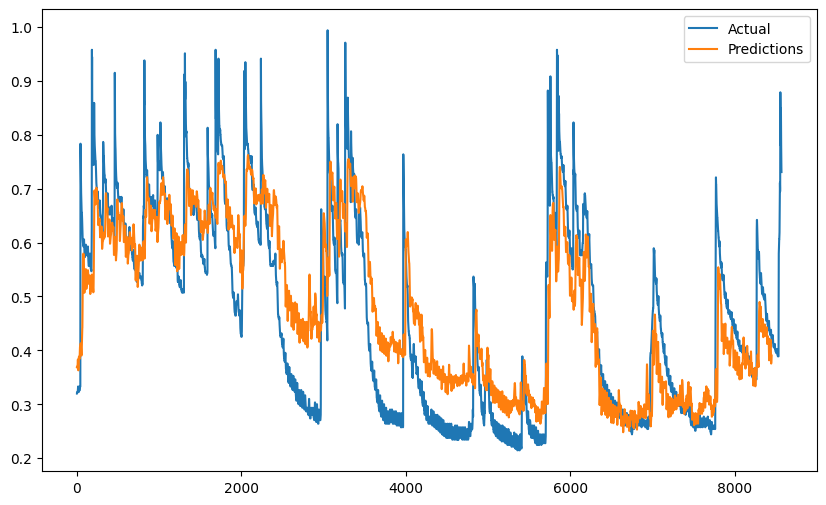

In [ ]:
plot_single_pred(lstm_model_A,'LSTMA', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step


{'Predictions': array([0.3604401 , 0.35838494, 0.35566399, ..., 0.36940506, 0.37140787,
        0.37223557], dtype=float32),
 'Actual': array([0.22180451, 0.22180451, 0.22180451, ..., 0.71052632, 0.69924812,
        0.69172932])}

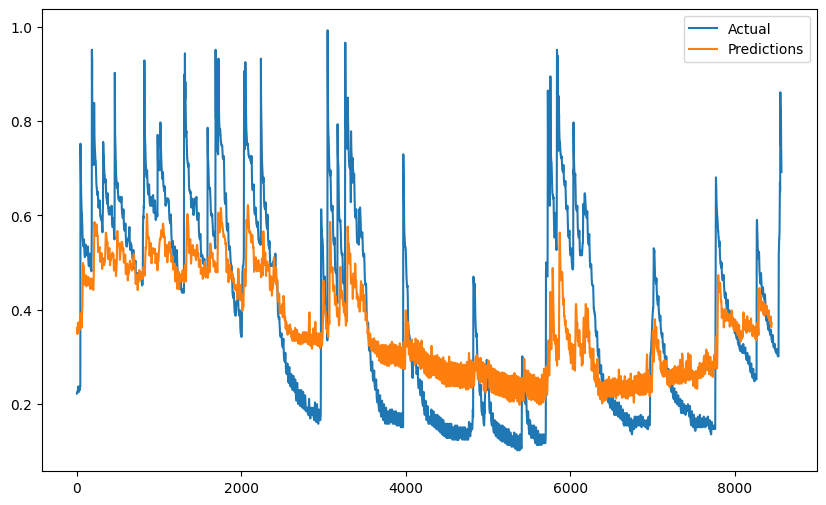

In [ ]:
plot_single_pred(lstm_model_B,'LSTMB', test_dataset1, test_steps1, y_test1, batch_size=BATCH_SIZE)